In [136]:
import pandas
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.pipeline import Pipeline  
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay, roc_curve, auc

In [137]:
BLACK = '\033[30m'
RED = '\033[31m'
GREEN = '\033[32m'
YELLOW = '\033[33m'
BLUE = '\033[34m'
MAGENTA = '\033[35m'
CYAN = '\033[36m'
LIGHT_GRAY = '\033[37m'
DARK_GRAY = '\033[90m'
BRIGHT_RED = '\033[91m'
BRIGHT_GREEN = '\033[92m'
BRIGHT_YELLOW = '\033[93m'
BRIGHT_BLUE = '\033[94m'
BRIGHT_MAGENTA = '\033[95m'
BRIGHT_CYAN = '\033[96m'
RESET = '\033[0m'

def colored_text(color, txt):
    return color + str(txt) + RESET

In [138]:
# Loading tables of this category across all years
datasets_path = "data"
years = [2019,2020, 2021, 2022, 2023, 2024]

df_usagers = []

for year in years:
    df_usagers_year = pandas.read_csv(os.path.join(datasets_path, str(year), f"usagers-{year}.csv"), encoding="utf-8", sep = ";")
    df_usagers.append(df_usagers_year)

df_usagers = pandas.concat(df_usagers)
df_usagers

,Num_Acc,id_vehicule,num_veh,place,catu,grav,sexe,an_nais,trajet,secu1,secu2,secu3,locp,actp,etatp,id_usager
0,201900000001,138 306 524,B01,2,2,4,2,2002.0,0,1,0,-1,-1,-1,-1,NaN
1,201900000001,138 306 524,B01,1,1,4,2,1993.0,5,1,0,-1,-1,-1,-1,NaN
2,201900000001,138 306 525,A01,1,1,1,1,1959.0,0,1,0,-1,-1,-1,-1,NaN
3,201900000002,138 306 523,A01,1,1,4,2,1994.0,0,1,0,-1,-1,-1,-1,NaN
4,201900000003,138 306 520,A01,1,1,1,1,1996.0,0,1,0,-1,-1,0,-1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125182,202400054401,155 686 119,Y01,1,1,4,2,1978.0,0,0,0,0,-1,-1,-1,203 859 570
125183,202400054401,155 686 120,A01,1,1,1,1,1984.0,0,2,6,0,-1,-1,-1,203 859 572
125184,202400054402,155 686 118,A01,1,1,4,1,1981.0,4,1,0,-1,-1,-1,-1,203 859 569
125185,202400054402,155 686 121,B01,1,1,4,2,1986.0,9,1,0,-1,-1,-1,-1,203 859 571


In [139]:
df_usagers.info()

<class 'pandas.DataFrame'>
Index: 745158 entries, 0 to 125186
Data columns (total 16 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Num_Acc      745158 non-null  int64  
 1   id_vehicule  745158 non-null  str    
 2   num_veh      745158 non-null  str    
 3   place        745158 non-null  int64  
 4   catu         745158 non-null  int64  
 5   grav         745158 non-null  int64  
 6   sexe         745158 non-null  int64  
 7   an_nais      734040 non-null  float64
 8   trajet       745158 non-null  int64  
 9   secu1        745158 non-null  int64  
 10  secu2        745158 non-null  int64  
 11  secu3        745158 non-null  int64  
 12  locp         745158 non-null  int64  
 13  actp         745158 non-null  str    
 14  etatp        745158 non-null  int64  
 15  id_usager    506886 non-null  str    
dtypes: float64(1), int64(11), str(4)
memory usage: 96.6 MB


In [140]:
# These features we are not going to use as we don't need to uniquely 
# identify a person and we have id_vehicule to link this table to the others
df_usagers.drop(columns=["num_veh", "id_usager"] ,inplace=True)

In [141]:
# Correcting typo errors and converting to right type
df_usagers["id_vehicule"] = (
    df_usagers["id_vehicule"]
    .astype(str)
    .str.replace(r"\D", "", regex=True)  # keeping only digits
    .astype("int64")
)

In [142]:
# Other attributes to correct errors and convert to int
column_names_to_int = ["place", "catu", "grav", "sexe", "an_nais", "trajet", "secu1", "secu2", "secu3", "locp", "actp", "etatp"]

df_usagers[column_names_to_int] = df_usagers[column_names_to_int].apply(
    lambda col: pandas.to_numeric(
        col.astype(str).str.extract(r'(-?\d+)')[0],
        errors="coerce"
    ),
    axis=0 # for each column
)
df_usagers.info()

<class 'pandas.DataFrame'>
Index: 745158 entries, 0 to 125186
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Num_Acc      745158 non-null  int64  
 1   id_vehicule  745158 non-null  int64  
 2   place        745158 non-null  int64  
 3   catu         745158 non-null  int64  
 4   grav         745158 non-null  int64  
 5   sexe         745158 non-null  int64  
 6   an_nais      734040 non-null  float64
 7   trajet       745158 non-null  int64  
 8   secu1        745158 non-null  int64  
 9   secu2        745158 non-null  int64  
 10  secu3        745158 non-null  int64  
 11  locp         745158 non-null  int64  
 12  actp         742496 non-null  float64
 13  etatp        745158 non-null  int64  
dtypes: float64(2), int64(12)
memory usage: 85.3 MB


In [143]:
# Next we are going to see the missing values proportion across different features
df_usagers.replace(-1, pandas.NA, inplace=True)
df_usagers["trajet"] = df_usagers["trajet"].replace(0, pandas.NA) # For trajet -1 and 0 mean missing value

for col in df_usagers.columns:
    prop = df_usagers[col].isna().sum() / df_usagers.shape[0]
    print(f"For {colored_text(MAGENTA, col)} proportion missing: {prop * 100:.2f}%")

For Num_Acc proportion missing: 0.00%
For id_vehicule proportion missing: 0.00%
For place proportion missing: 0.00%
For catu proportion missing: 0.00%
For grav proportion missing: 0.06%
For sexe proportion missing: 1.43%
For an_nais proportion missing: 1.49%
For trajet proportion missing: 27.76%
For secu1 proportion missing: 1.34%
For secu2 proportion missing: 40.63%
For secu3 proportion missing: 97.31%
For locp proportion missing: 45.88%
For actp proportion missing: 42.05%
For etatp proportion missing: 92.18%


In [144]:
# we can notice that for trajet we have many missing data, but before removing this column, 
# we want to keep this feature to see if it can help us in our target prediction, so let's replace missing values with 0 for now
# we are going to check its importance later in the correlation matrix
df_usagers["trajet"] = df_usagers["trajet"].replace(pandas.NA, 0)

In [145]:
# These features we are 100% sure going to use in all tests and as 
# it would be very hard to impute if missing, thus we are deleting rows where these values are missing
# but let's still check that the proportion is not too big
before = len(df_usagers)
df_usagers = df_usagers.dropna(subset=["grav", "sexe", "an_nais", "place", "catu"])
after = len(df_usagers)

print(f"Removed {before-after} rows ({(before-after)/before*100:.2f}%)")

Removed 11139 rows (1.49%)


As for secu1, secu2 and secu3 these are important but we have ot convert these into more meaningfull and usable form.

For this, let's see their distribution and how they relate to gravity

In [146]:
equipments = {
    0: "aucun",
    1: "ceinture",
    2: "casque",
    3: "dispositif_enfant",
    4: "gilet_reflechissant",
    5: "airbag",
    6: "gants",
    7: "gants_airbag",
    8: "non determinable",
    9: "autre"
}

# function to pass from secu1, secu2, secu3 to one hot-encoding with some changes specific to our dataset
def encode_secu(df):
    # Initialize columns EXCEPT gants_airbag, because 
    # it means gants and airbag so just converting into these 2 categories
    for name in equipments.values():
        if name != "gants_airbag":
            df[name] = 0

    for col in ["secu1", "secu2", "secu3"]:
        for code, name in equipments.items():
            if name == "gants_airbag":
                df.loc[df[col] == code, "gants"] = 1
                df.loc[df[col] == code, "airbag"] = 1
            else:
                df.loc[df[col] == code, name] = 1

    # if any equipment used, we set aucun = 0
    protection_cols = [c for c in equipments.values() if c not in ["aucun", "gants_airbag"]]
    df.loc[df[protection_cols].sum(axis=1) > 0, "aucun"] = 0

    return df

# applying the function and deleting the columns
df_usagers = encode_secu(df_usagers)    
df_usagers.drop(columns=["secu1", "secu2", "secu3"] ,inplace=True)

In [147]:
# As protection is a quite important attribute, we though to see how having no protection 
# can affect severity of and accident, excluding pedestrians, as they don't have protection is any case.
df_no_protection = df_usagers[
    (df_usagers["aucun"] == 1) &
    (df_usagers["catu"] != 3)
] # without pedestrians

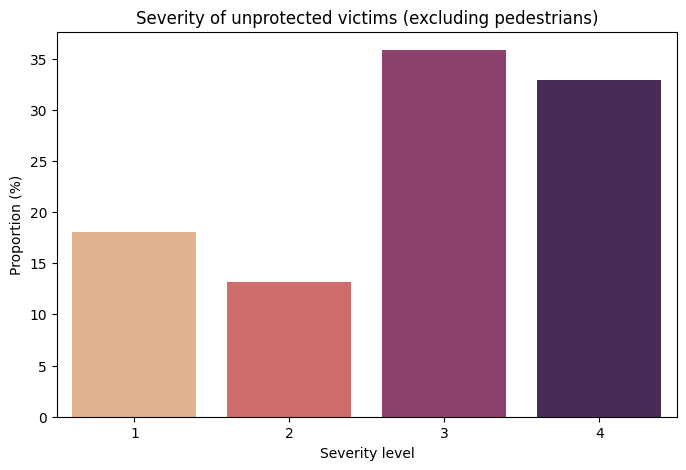

In [148]:
# After plotting, we can clearly obesrve a bigger proportion in severe accidents
plt.figure(figsize=(8,5))
sns.countplot(
    data=df_no_protection,
    x="grav",
    hue="grav",
    stat="percent",
    palette="flare",
    legend=False
)

plt.title("Severity of unprotected victims (excluding pedestrians)")
plt.xlabel("Severity level")
plt.ylabel("Proportion (%)")
plt.show()

In [149]:
# next, we convert the year of birth into age
# df_usagers["Num_Acc"][:4] -> contains year
df_usagers["year_acc"] = df_usagers["Num_Acc"].astype(str).str[:4]
df_usagers["year_acc"] = pandas.to_numeric(df_usagers["year_acc"], errors="coerce")

df_usagers["age"] = df_usagers["year_acc"] - df_usagers["an_nais"]
df_usagers.drop(columns=["an_nais", "year_acc"], inplace=True)

In [150]:
# seeing the distribution
df_usagers["age"].describe()

count    734019.000000
mean         38.583199
std          19.018723
min           0.000000
25%          23.000000
50%          35.000000
75%          52.000000
max         120.000000
Name: age, dtype: float64

In [151]:
len(df_usagers[df_usagers["age"] > 100])

221

In [152]:
df_usagers[df_usagers["age"] > 100]["age"].value_counts().sort_index()

age
101.0      9
102.0      5
103.0      1
104.0      1
106.0      1
108.0      1
109.0      7
110.0      5
118.0     43
119.0    133
120.0     15
Name: count, dtype: int64

In [153]:
# deleting strange ages
df_usagers = df_usagers[df_usagers["age"] <= 100]

<Axes: xlabel='age', ylabel='Count'>

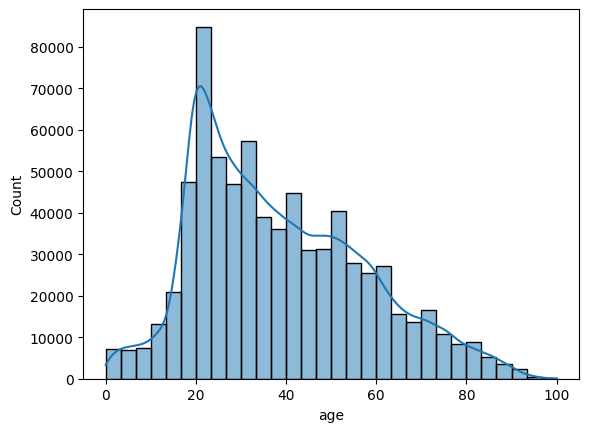

In [154]:
# distribution of age feature after removing (looks legitimate)
sns.histplot(df_usagers["age"], bins=30, kde=True) 

In [155]:
# specifically for pedestrians, the feature "place" (=10 for pedestrians) should be the same as "catu" (=3 for pedestrians)
# so we need to check whetether there are mistakes and drop rows when information differ, 
# as it is contradiction and we have no way to obtain the real category
incoherences = df_usagers[
    ((df_usagers["place"] == 10) & (df_usagers["catu"] != 3)) |
    ((df_usagers["catu"] == 3) & (df_usagers["place"] != 10))
]

print("Number of inconsistent examples : ",  len(incoherences))

# Nothing to correct here

Number of inconsistent examples :  0


In [156]:
# we have decided to do binary classification, so we design our target
df_usagers["grav_bin"] = df_usagers["grav"].replace({
    1: 0,  # Unharmed -> not severe
    4: 0,  # Minor injury -> not severe
    2: 1,  # Killed -> severe
    3: 1   # Hospitalized injury -> severe
})

In [157]:
# Prinitng the proportion of target labels in our dataset
mapping = {
    0: "Not severly injured",
    1: "Severly injured"
}

counts = df_usagers["grav_bin"].value_counts()
counts.index = counts.index.map(mapping)

for cl, prop in counts.items():
    print(f"For {colored_text(MAGENTA, cl)} proportion: {prop / len(df_usagers) * 100:.2f}%")

For Not severly injured proportion: 81.71%
For Severly injured proportion: 18.29%


In [158]:
# We can also take a look at more specific target lables
mapping = {
    1: "Unharmed",
    2: "Killed",
    3: "Hospitalized injury",
    4: "Minor injury"
}

counts = df_usagers["grav"].value_counts()
counts.index = counts.index.map(mapping)

for cl, prop in counts.items():
    print(f"For {colored_text(MAGENTA, cl)} proportion: {prop / len(df_usagers) * 100:.2f}%")

For Unharmed proportion: 41.27%
For Minor injury proportion: 40.44%
For Hospitalized injury proportion: 15.59%
For Killed proportion: 2.71%


In [159]:
# as we have converted empty values into 
cols_int = ["place", "catu", "sexe", "age", "aucun", "ceinture", "casque", "dispositif_enfant", "gilet_reflechissant", "airbag", "non determinable", "gants", "autre", "grav_bin", "grav"]
df_usagers[cols_int] = df_usagers[cols_int].astype("int64")

In [160]:
# Defining all features that are going to be used
features = ['place', 'catu', 'sexe', 'age', 
       'aucun', 'ceinture', 'casque', 'dispositif_enfant',
       'gilet_reflechissant', 'airbag', 'gants', 'autre', "non determinable"]

# We need to separate by category as the preprocessing will differ
binary_features = ['aucun', 'ceinture', 'casque', 'dispositif_enfant', 'gilet_reflechissant', 'airbag', 'gants', 'autre', "non determinable"]
numerical_features = ["age"]
categorical_features = list(set(features) - set(binary_features) - set(numerical_features))

target = 'grav_bin'

In [161]:
# Let's do analysis of our features distribution and see the proportion in each of target labels

# to simplify the visualisation let's replace numeric categories with strings
df_usagers_analyse = df_usagers.copy()

mapping = {
    0: "Absent",
    1: "Present"
}
pres_abs_features = [
    'aucun', 'ceinture', 'casque', 'dispositif_enfant',
    'gilet_reflechissant', 'airbag', 'gants', 'autre', "non determinable"
]
df_usagers_analyse[pres_abs_features] = df_usagers_analyse[pres_abs_features].replace(mapping)

mapping = {
    1: "Driver",
    2: "Front right passenger",
    3: "Rear right passenger",
    4: "Rear left passenger",
    5: "Front left passenger",
    6: "Other seat in light vehicle",
    7: "Public transport – seated",
    8: "Public transport – standing",
    9: "Other public transport",
    10: "Pedestrian (not applicable)"
}

df_usagers_analyse["place"] = df_usagers_analyse["place"].replace(mapping)

mapping = {
    1: "Driver",
    2: "Passenger",
    3: "Pedestrian"
}
df_usagers_analyse["catu"] = df_usagers_analyse["catu"].replace(mapping)

mapping = {
    1: "Male",
    2: "Female"
}
df_usagers_analyse["sexe"] = df_usagers_analyse["sexe"].replace(mapping)

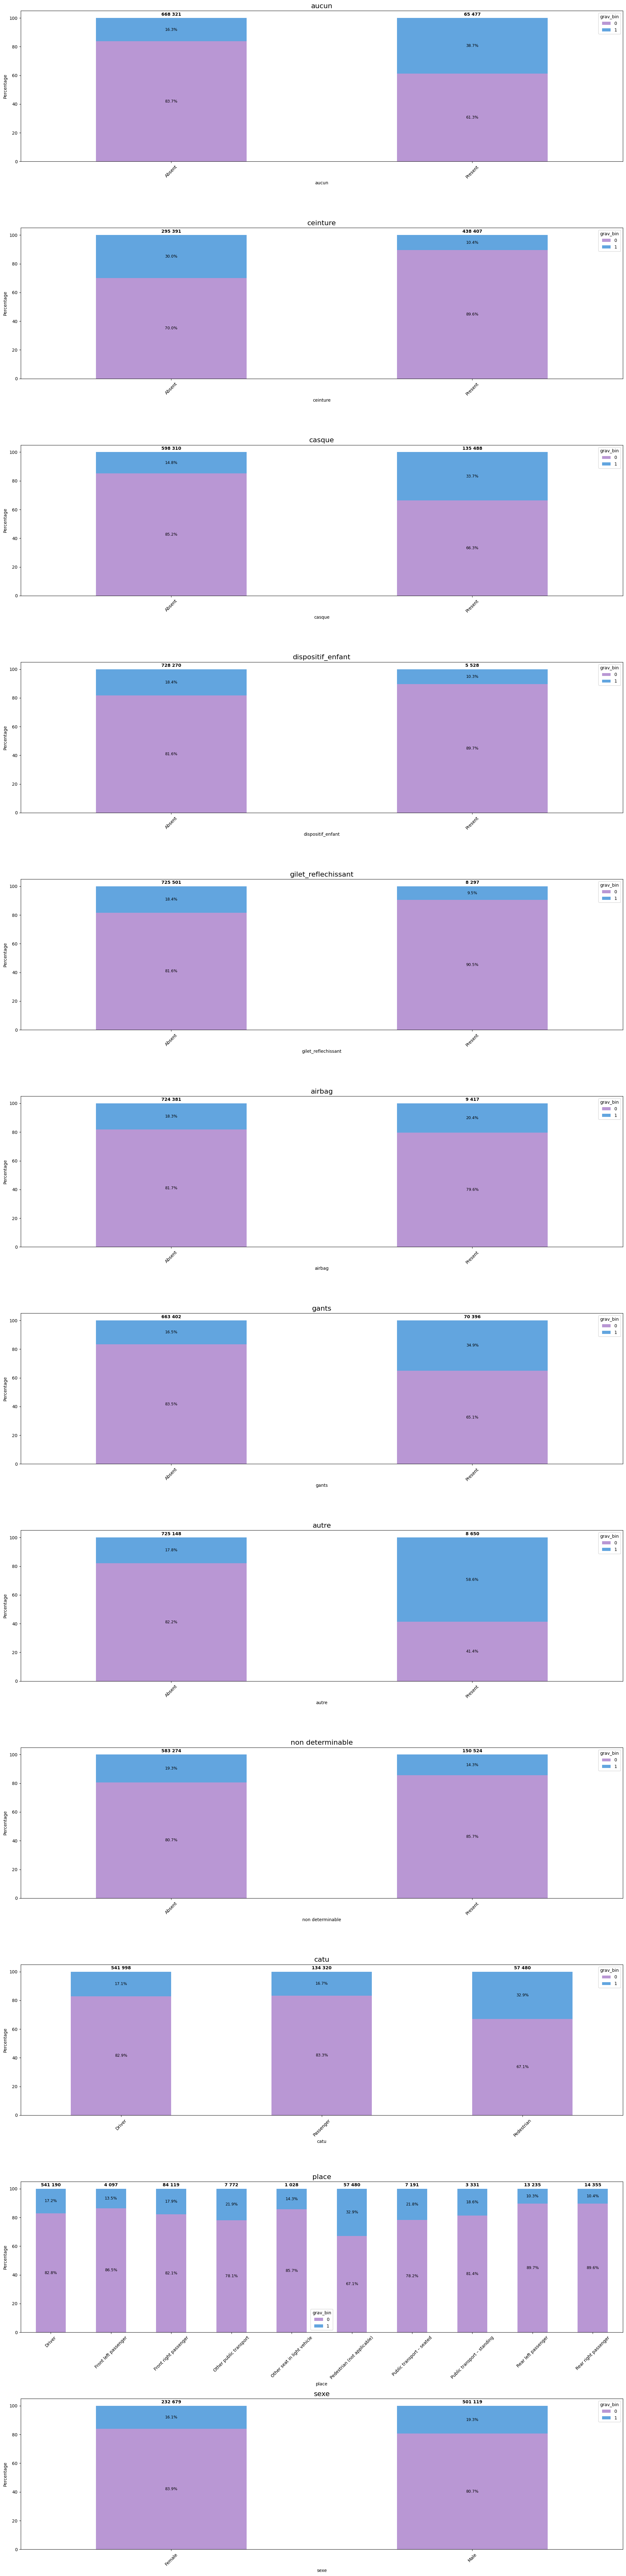

In [162]:
features_to_analyse = binary_features + categorical_features

fig, ax = plt.subplots(len(features_to_analyse), 1, figsize=(20, 6*len(features_to_analyse) + 10))

df_usagers_analyse = df_usagers_analyse.reset_index(drop=True)

for i, feature in enumerate(features_to_analyse):
    ct = pandas.crosstab(
        df_usagers_analyse[feature],
        df_usagers_analyse[target],
        normalize="index"
    ) * 100

    counts = df_usagers_analyse[feature].value_counts().sort_index()

    # Plot
    ct.plot(kind="bar", stacked=True, ax=ax[i], color=["#B997D4", "#62A5DF"])

    # Add % labels inside bars
    for j, category in enumerate(ct.index):
        cumulative = 0
        for k, col in enumerate(ct.columns):
            value = ct.loc[category, col]
            if value > 3:  # avoid clutter for tiny values
                ax[i].text(
                    j,
                    cumulative + value / 2,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="black"
                )
            cumulative += value

    # Add total count above bars
    for j, category in enumerate(ct.index):
        ax[i].text(
            j,
            101,
            f"{counts[category]:,}".replace(",", " "),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    ax[i].set_title(feature, fontsize=16)
    ax[i].tick_params(axis='x', rotation=45)
    ax[i].set_ylabel("Percentage")

plt.tight_layout()

In [163]:
# To generate LaTeX compact table with counts per class and all proportions

def latex_escape_category(x):
    x = str(x)

    # Make the text LaTeX safe
    x = x.replace("<=", r"$\le$")
    x = x.replace(">=", r"$\ge$")
    x = x.replace("<", r"$<$")
    x = x.replace(">", r"$>$")

    x = x.replace("&", r"\&")
    x = x.replace("%", r"\%")
    x = x.replace("_", r"\_")
    x = x.replace("#", r"\#")

    return x

output_lines = []

for feature in features_to_analyse:
    counts = df_usagers_analyse.groupby(feature)[target].value_counts().unstack(fill_value=0)
    proportions = counts.div(counts.sum(axis=1), axis=0) * 100

    for i, category in enumerate(counts.index):
        category_latex = latex_escape_category(category)
        count = counts.loc[category].sum()
        not_severe = proportions.loc[category].get(0, 0)
        severe = proportions.loc[category].get(1, 0)

        if i == 0:
            line = f"\\texttt{{{feature}}} & {category} & {count:,} & {not_severe:.1f} & {severe:.1f} \\\\"
        else:
            line = f" & {category} & {count:,} & {not_severe:.1f} & {severe:.1f} \\\\"

        line = line.replace(",", " ")

        output_lines.append(line)

    output_lines.append("\\hline")

print("\n".join(output_lines))

\texttt{aucun} & Absent & 668 321 & 83.7 & 16.3 \\
 & Present & 65 477 & 61.3 & 38.7 \\
\hline
\texttt{ceinture} & Absent & 295 391 & 70.0 & 30.0 \\
 & Present & 438 407 & 89.6 & 10.4 \\
\hline
\texttt{casque} & Absent & 598 310 & 85.2 & 14.8 \\
 & Present & 135 488 & 66.3 & 33.7 \\
\hline
\texttt{dispositif_enfant} & Absent & 728 270 & 81.6 & 18.4 \\
 & Present & 5 528 & 89.7 & 10.3 \\
\hline
\texttt{gilet_reflechissant} & Absent & 725 501 & 81.6 & 18.4 \\
 & Present & 8 297 & 90.5 & 9.5 \\
\hline
\texttt{airbag} & Absent & 724 381 & 81.7 & 18.3 \\
 & Present & 9 417 & 79.6 & 20.4 \\
\hline
\texttt{gants} & Absent & 663 402 & 83.5 & 16.5 \\
 & Present & 70 396 & 65.1 & 34.9 \\
\hline
\texttt{autre} & Absent & 725 148 & 82.2 & 17.8 \\
 & Present & 8 650 & 41.4 & 58.6 \\
\hline
\texttt{non determinable} & Absent & 583 274 & 80.7 & 19.3 \\
 & Present & 150 524 & 85.7 & 14.3 \\
\hline
\texttt{catu} & Driver & 541 998 & 82.9 & 17.1 \\
 & Passenger & 134 320 & 83.3 & 16.7 \\
 & Pedestrian &

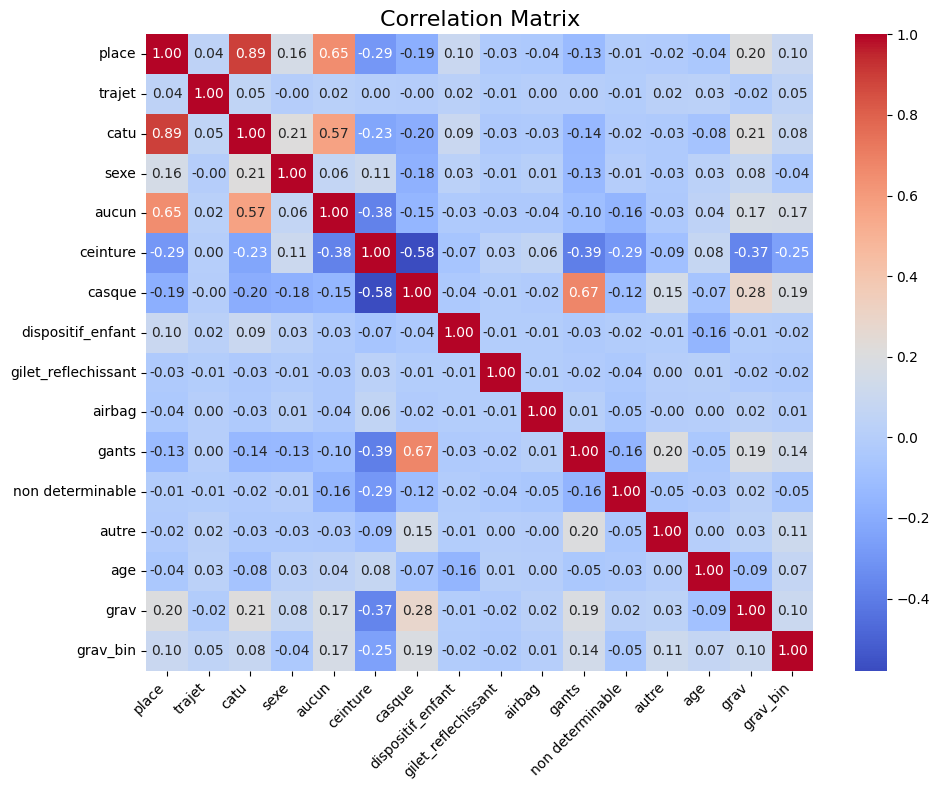

In [164]:
# Let's see the correlations between features
plt.figure(figsize=(10, 8))

sns.heatmap(
    df_usagers[['place', 'trajet', 'catu', 'sexe', 'aucun', 'ceinture', 'casque',
       'dispositif_enfant', 'gilet_reflechissant', 'airbag', 'gants', 'non determinable',
       'autre', 'age', 'grav', 'grav_bin']].corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10}
)

plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [165]:
# let's see how at this stage we can predict our target label
# first we are splitting the dataset on test and train
X = df_usagers[features]
y = df_usagers[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20, stratify=y)

In [166]:
# defining preprocessing depending on the type of the feature
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features),
        ("bin", "passthrough", binary_features)
    ]
)

# our ML models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=20),
    "Decision Tree": DecisionTreeClassifier(random_state=20),
    "Gradient Boosting": GradientBoostingClassifier(random_state=20)
}

# we are going to test with oversampling and undersampling
pipelines_over = {}
pipelines_under = {}
for name, model in models.items():
    pipelines_over[name] = Pipeline([
        ("preprocessing", preprocessor),
        ("sampling", RandomOverSampler(random_state=20)),
        ("model", model)
    ])
    pipelines_under[name] = Pipeline([
        ("preprocessing", preprocessor),
        ("sampling", RandomUnderSampler(random_state=20)),
        ("model", model)
    ])

# First we are doing cross-validation of our models with oversampling
print(colored_text(BRIGHT_BLUE, "Models evaluation with oversampling"))
for name, pipe in pipelines_over.items():
    y_pred = cross_val_predict(pipe, X_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=20))
    
    precision = precision_score(y_train, y_pred)
    recall = recall_score(y_train, y_pred)
    f1 = f1_score(y_train, y_pred)
    accuracy = accuracy_score(y_train, y_pred)

    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)

    print(classification_report(y_train, y_pred))

# Then we are doing cross-validation of our models with undersampling
print(colored_text(BRIGHT_BLUE, "Models evaluation with undersampling"))
for name, pipe in pipelines_under.items():
    y_pred = cross_val_predict(pipe, X_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=20))
    
    precision = precision_score(y_train,y_pred)
    recall = recall_score(y_train, y_pred)
    f1 = f1_score(y_train,y_pred)
    accuracy = accuracy_score(y_train, y_pred)

    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)

    print(classification_report(y_train, y_pred))

Models evaluation with oversampling

 Logistic Regression
Precision: 0.33068249739137484
Recall: 0.6078980939167358
F1: 0.42835162311566033
Accuracy: 0.703175944317063
              precision    recall  f1-score   support

           0       0.89      0.72      0.80    479645
           1       0.33      0.61      0.43    107393

    accuracy                           0.70    587038
   macro avg       0.61      0.67      0.61    587038
weighted avg       0.79      0.70      0.73    587038


 Decision Tree
Precision: 0.32410714285714287
Recall: 0.6320803031854962
F1: 0.4284970315592126
Accuracy: 0.6915514838903103
              precision    recall  f1-score   support

           0       0.90      0.70      0.79    479645
           1       0.32      0.63      0.43    107393

    accuracy                           0.69    587038
   macro avg       0.61      0.67      0.61    587038
weighted avg       0.79      0.69      0.72    587038


 Gradient Boosting
Precision: 0.3304707560627675
Re

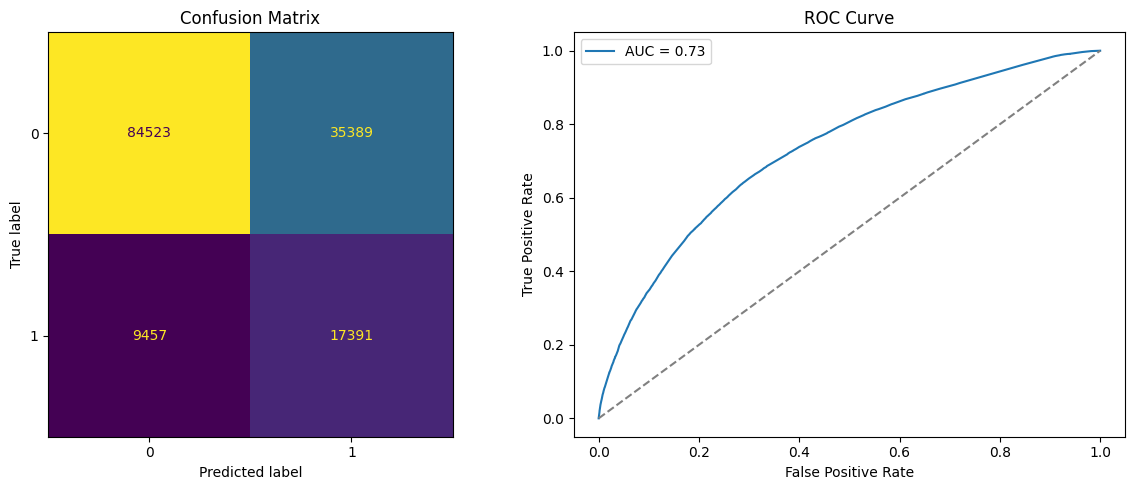

In [167]:
# Finally, we are going to take the best model among the previously trained and select the best one according to f1 score 
# and test it on the test set
# according to the previous prints the models perform approximatively on the same level, so we can take for example 
# Gradient boosting with overfitting which shows slighlty better results for class 1 (severe)

# Train and predict
model = pipelines_over["Gradient Boosting"]
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
axes[1].plot([0, 1], [0, 1], linestyle='--', color='grey')
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

Furthermore, we also wanted to take a look at a particular category: pedestrians.

In [168]:
# We are filtering only pedestrians in our dataset
df_pedestrians = df_usagers[df_usagers["catu"] == 3]

In [169]:
# we are definifn specific set of features for pedestrians
features_pedestrians = ['sexe', 'locp', 'actp', 'etatp', 'age',"aucun", "gilet_reflechissant", 'autre', 'non determinable']
target = "grav_bin"

# and dropping rows when these features are empty
df_pedestrians_n = df_pedestrians.dropna(subset=features_pedestrians)

In [170]:
print(f"Proportion of pedestrians taken after removing empty lines: {len(df_pedestrians_n) / len(df_pedestrians)*100:.3f} %")
print(f"Final number of examples: {len(df_pedestrians_n)}")

Proportion of pedestrians taken after removing empty lines: 94.379 %
Final number of examples: 54249


In [171]:
# Prinitng the proportion of target labels in our pedestrians dataset
mapping = {
    0: "Not severly injured",
    1: "Severly injured"
}

counts = df_pedestrians_n["grav_bin"].value_counts()
counts.index = counts.index.map(mapping)

for cl, prop in counts.items():
    print(f"For {colored_text(MAGENTA, cl)} proportion: {prop / len(df_pedestrians_n) * 100:.2f}%")

For Not severly injured proportion: 67.44%
For Severly injured proportion: 32.56%


In [172]:
# seeing what methods of security are present in how many rows (these are the only binary features)
df_pedestrians_n[binary_features].sum()

aucun                  43102
ceinture                   0
casque                     0
dispositif_enfant          0
gilet_reflechissant      251
airbag                     0
gants                      0
autre                    155
non determinable       10629
dtype: int64

In [173]:
# sorting features by category
numerical_features = ["age"]
binary_features = ["aucun", "gilet_reflechissant", 'autre', 'non determinable']
categorical_features = list(set(features_pedestrians) - set(numerical_features) - set(binary_features))


In [174]:
# splitting the set into training and testing
X = df_pedestrians_n[features_pedestrians]
y = df_pedestrians_n[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20, stratify=y)

In [175]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features),
        ("bin", "passthrough", binary_features)
    ]
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=20),
    "Decision Tree": DecisionTreeClassifier(random_state=20),
    "Gradient Boosting": GradientBoostingClassifier(random_state=20)
}

pipelines = {
    name: Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])
    for name, model in models.items()
}

for name, pipe in pipelines.items():
    y_pred = cross_val_predict(pipe, X_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=20))
    
    precision = precision_score(y_train,y_pred)
    recall = recall_score(y_train, y_pred)
    f1 = f1_score(y_train,y_pred)
    accuracy = accuracy_score(y_train, y_pred)

    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)

    print(classification_report(y_train, y_pred))


 Logistic Regression
Precision: 0.5681019332161688
Recall: 0.18298896122275687
F1: 0.27681438664097624
Accuracy: 0.6886564206548538
              precision    recall  f1-score   support

           0       0.70      0.93      0.80     29267
           1       0.57      0.18      0.28     14132

    accuracy                           0.69     43399
   macro avg       0.64      0.56      0.54     43399
weighted avg       0.66      0.69      0.63     43399


 Decision Tree
Precision: 0.4775713638423199
Recall: 0.2983300311350127
F1: 0.3672473867595819
Accuracy: 0.6652457429894698
              precision    recall  f1-score   support

           0       0.71      0.84      0.77     29267
           1       0.48      0.30      0.37     14132

    accuracy                           0.67     43399
   macro avg       0.60      0.57      0.57     43399
weighted avg       0.64      0.67      0.64     43399


 Gradient Boosting
Precision: 0.575452422650321
Recall: 0.27901217095952446
F1: 0.37581

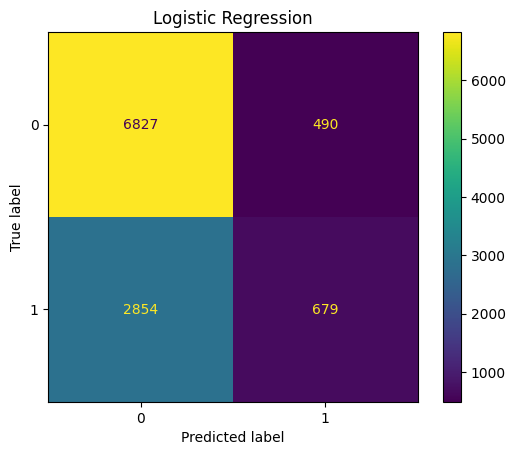

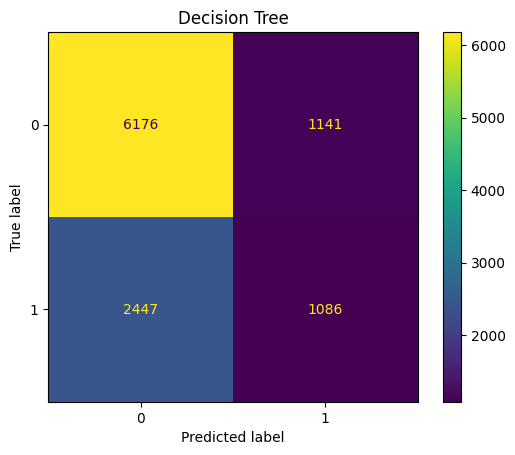

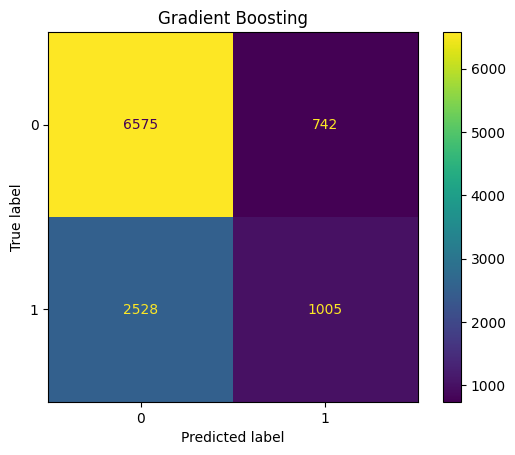

In [176]:
for name, model in pipelines.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(name)
    plt.show()

In [177]:
# Finally we are going to save the dataset cleaned
df_usagers.to_csv("df_usagers_clean.csv", index=False)